# TWITTER SENTIMENT ANALYSIS OF APPLE AND GOOGLE PRODUCTS USING NATURAL LANGUAGE PROCESSING 

 Author:Nanjala Simiyu

# 1. BUSINESS UNDERSTANDING #

# 1.1.Business Context

 Apple and Google operate in a highly competitive, fast-paced consumer tech market. Customer sentiment on social media shifts rapidly in response to product launches, software updates, and public relations events.

# 1.2 Business Problem

Apple and Google receive thousands of Tweets daily discussing their products and services. Brand managers, product teams, and customer success representatives cannot manually review and categorize such large volumes of social media data to understand public opinion. As a result, important product issues reflected in negative sentiment may go unnoticed, while opportunities arising from positive customer feedback may not be fully leveraged. Therefore, there is a need for an automated Natural Language Processing (NLP) solution that can classify Tweets as positive, negative, or neutral, enabling timely insights and better business decision-making.

# 1.3 Stakeholders

These are the people who will use or benefit from the results of this model:

Brand Managers (Apple & Google) – Monitor public perception and brand reputation.

Product Teams – Identify product issues, bugs, or feature feedback from users.

Customer Success / Support Teams – Understand customer complaints and improve response strategies.

Marketing Teams – Identify positive sentiment to amplify successful campaigns.

Business Executives – Use insights for strategic decision-making.

# 1.4 Business Questions

What is the overall sentiment (positive, negative, or neutral) expressed in Tweets about Apple and Google products on Twitter?

Can a machine learning model accurately identify negative tweets to ensure that critical customer issues are quickly detected and addressed?

Which Apple and Google products or features generate the most positive and negative customer feedback?

# 1.5 Project Objectives

# General Objectives

To develop a Natural Language Processing (NLP) model that automatically classifies Tweets about Apple and Google products into sentiment categories (positive, negative, and neutral) to support customer insight and decision-making.

# Specific Objectives

To clean and preprocess Twitter text data for sentiment analysis.

To explore and understand the distribution of sentiments in the dataset.

To transform text data into numerical features using NLP techniques such as TF-IDF.

To build a machine learning model that classifies Tweets into positive, negative, and neutral sentiment.

To evaluate the performance of the model using appropriate metrics such as F1-score, precision, and recall.

To identify and analyze negative Tweets for early detection of customer issues.

To generate insights on which Apple and Google products or features drive positive and negative sentiment.

# 2 DATA UNDERSTANDING

# 2.1 Data Source

The dataset comes from CrowdFlower via data.world.It contains Tweets related to Apple and Google products, where human annotators labeled each Tweet according to its sentiment.

# 2.2 Dimensions
Number of observations (rows): ~9,000+ Tweets and 3 columns


# 2.3 Column names and Data Types

Tweet_text (Object/String): The raw text of the tweet ($9,092$ non-null values, $1$ missing value).

Emotion_in_tweet_is_directed_at (Object/String): The specific product or brand being targeted ($3,291$ non-null values, high missingness).

Is_there_an_emotion_directed_at_a_brand_or_product (Object/String): Our target label ($9,093$ non-null values).

# 2.4 Target Variable
Positive

Negative

Neutral (or Neither)


In [124]:

#importing libraries
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting aesthetics
sns.set_theme(style="whitegrid")
%matplotlib inline

# NLP preprocessing
import re
import string

# NLTK tools
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 3.LOADING, INSPECTION  AND CLEANING OF DATA

# 3.1 Data loading&Inspection

In [125]:
# 1. Load dataset
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding='unicode_escape')

In [126]:
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [128]:
df.shape

(9093, 3)

In [129]:
df.value_counts

<bound method DataFrame.value_counts of                                              tweet_text  \
0     .@wesley83 I have a 3G iPhone. After 3 hrs twe...   
1     @jessedee Know about @fludapp ? Awesome iPad/i...   
2     @swonderlin Can not wait for #iPad 2 also. The...   
3     @sxsw I hope this year's festival isn't as cra...   
4     @sxtxstate great stuff on Fri #SXSW: Marissa M...   
...                                                 ...   
9088                      Ipad everywhere. #SXSW {link}   
9089  Wave, buzz... RT @mention We interrupt your re...   
9090  Google's Zeiger, a physician never reported po...   
9091  Some Verizon iPhone customers complained their...   
9092  Ï¡Ïàü_ÊÎÒ£Áââ_£â_ÛâRT @...   

     emotion_in_tweet_is_directed_at  \
0                             iPhone   
1                 iPad or iPhone App   
2                               iPad   
3                 iPad or iPhone App   
4                             Google   
...        

# 3.2 Data Cleaning

In [130]:
# Rename columns to make them easier to type
df.columns = ['text', 'product', 'sentiment']

In [131]:
#handle missing values
df.isna().value_counts()#checking the missing values

text   product  sentiment
False  True     False        5801
       False    False        3291
True   True     False           1
dtype: int64

In [132]:
# Drop rows where the actual tweet text is missing
df = df.dropna(subset=['text'])

In [133]:
print("Dataset Shape:", df.shape)
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

Dataset Shape: (9092, 3)

Sentiment Distribution:
No emotion toward brand or product    5388
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: sentiment, dtype: int64


In [134]:
#Filter Out Target Ambiguity 
# Remove human annotator noise ("I can't tell") to preserve definitive sentiment vectors
df = df[df['sentiment'] != "I can't tell"]

In [135]:
# Target: 'sentiment' contains no missing values, but 'tweet_text' has 1 null row.
#drop the missing values
cleaned_df =df.dropna(subset=['text']).copy()

In [136]:
#checking for duplicates
duplicate_count = df.duplicated(subset=['text']).sum()
duplicate_count

27

In [137]:
# Create a dedicated Twitter normalization block
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'rt\s+@\w+', '', text)              # Remove Retweet handles
    text = re.sub(r'@\w+', '', text)                   # Remove Standard mentions
    text = re.sub(r'{link}', '', text)                 # Remove web links
    text = re.sub(r'&amp;|&quot;|&lt;|&gt;', ' ', text) # Strip raw HTML escape blocks
    text = re.sub(r'[^\w\s]', '', text)                # Remove leftover standalone punctuation
    return " ".join(text.split())                      # Normalize spacing

# Apply the text clean function
cleaned_df['clean_text'] = cleaned_df['text'].apply(clean_tweet)

In [138]:
#drop the duplicates
cleaned_df = cleaned_df.drop_duplicates(subset=['text'], keep='first')

In [139]:
#Target numerical encoding
#cast text classes into machine-readable format
target_encoder = {
    'Negative emotion': 0,
    'No emotion toward brand or product': 1,
    'Positive emotion': 2
}
cleaned_df['label'] = cleaned_df['sentiment'].map(target_encoder)

print(f"Final post-cleaned dataframe structural dimensions: {cleaned_df.shape}\n")

Final post-cleaned dataframe structural dimensions: (8909, 5)



In [140]:
#check for multicollinearity
print("--- MULTICOLLINEARITY ANALYSIS VIA VARIANCE INFLATION FACTOR (VIF) ---")

--- MULTICOLLINEARITY ANALYSIS VIA VARIANCE INFLATION FACTOR (VIF) ---


In [141]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Feature Engineering
cleaned_df['char_length'] = cleaned_df['text'].apply(len)
cleaned_df['word_count'] = cleaned_df['text'].apply(lambda x: len(x.split()))

# 2. Isolate raw numeric features (dropping avg_word_length to remove strict redundancy)
numerical_features = ['char_length', 'word_count']
vif_matrix = cleaned_df[numerical_features].dropna()

# 3. CRITICAL: Add an intercept/constant column for proper linear regression scaling
vif_matrix_with_const = add_constant(vif_matrix)

# 4. Compute VIF coefficients (skipping the constant column in the final printout)
vif_data = pd.DataFrame()
# Start the loop at 1 if you want to exclude displaying the VIF of the constant itself
vif_data["Feature"] = vif_matrix.columns
vif_data["VIF_Score"] = [
    variance_inflation_factor(vif_matrix_with_const.values, i) 
    for i in range(1, len(vif_matrix_with_const.columns)) 
]

print(vif_data.round(2))

       Feature  VIF_Score
0  char_length       5.02
1   word_count       5.02


VIF analysis showed moderate multicollinearity between character length and word count (VIF = 5.02). This is expected because longer tweets naturally contain more words. The multicollinearity was not severe, so both features were retained.

# 4. EXPLORATORY DATA ANALYSIS (EDA)

In [142]:
#feature engineering
cleaned_df['tweet_length'] = cleaned_df['text'].apply(len)
cleaned_df['word_count'] = cleaned_df['text'].apply(lambda x: len(x.split()))
print(cleaned_df['tweet_length'] )
print(cleaned_df['word_count'])

0       127
1       139
2        79
3        82
4       131
       ... 
9088     29
9089    125
9090    145
9091    140
9092    104
Name: tweet_length, Length: 8909, dtype: int64
0       23
1       22
2       15
3       15
4       17
        ..
9088     4
9089    18
9090    19
9091    23
9092     9
Name: word_count, Length: 8909, dtype: int64


4.1 Class Imbalance Visualization

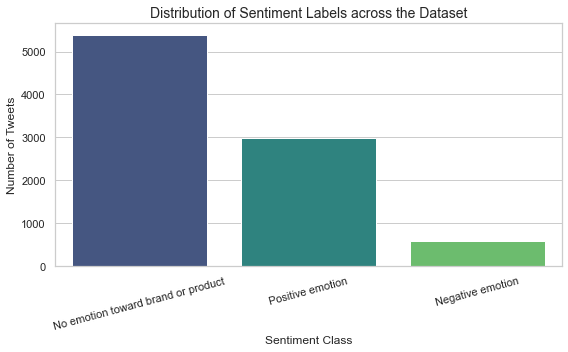

In [143]:

import matplotlib.pyplot as plt
import seaborn as sns
# Plot target distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment', order=df['sentiment'].value_counts().index, palette='viridis')
plt.title('Distribution of Sentiment Labels across the Dataset', fontsize=14)
plt.ylabel('Number of Tweets')
plt.xlabel('Sentiment Class')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

 4.2 Tweet Length vs. Sentiment

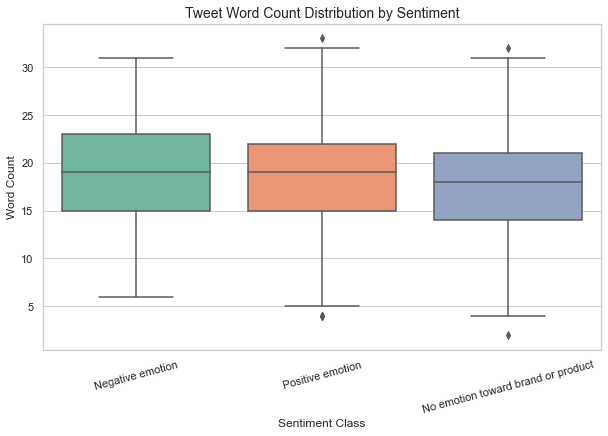

In [144]:
# Calculate tweet lengths
df['char_count'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

# Plot Word Count Distribution by Sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sentiment', y='word_count', palette='Set2')
plt.title('Tweet Word Count Distribution by Sentiment', fontsize=14)
plt.xlabel('Sentiment Class')
plt.ylabel('Word Count')
plt.xticks(rotation=15)
plt.show()

4.3 Brand & Product Breakdown

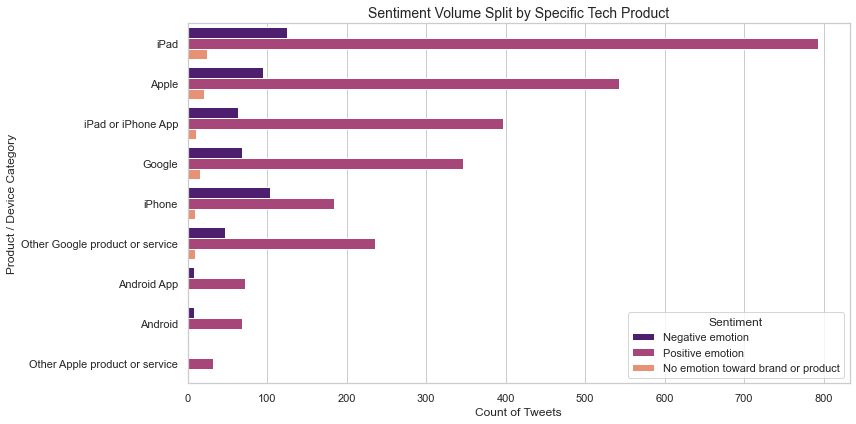

In [145]:
# Filter out rows where product metadata is missing
product_df = df.dropna(subset=['product'])

plt.figure(figsize=(12, 6))
sns.countplot(data=product_df, y='product', hue='sentiment', 
              order=product_df['product'].value_counts().index, palette='magma')
plt.title('Sentiment Volume Split by Specific Tech Product', fontsize=14)
plt.xlabel('Count of Tweets')
plt.ylabel('Product / Device Category')
plt.legend(title='Sentiment', loc='lower right')
plt.tight_layout()
plt.show()

# 5. Model Building/Evaluation


In [146]:
# Update your data splitting layer to utilize the cleaned column
X = cleaned_df['clean_text']
y = cleaned_df['label']

In [147]:
#split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [148]:
#Convert Text to Features (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2), 
    stop_words='english'
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [149]:
#modelling and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Define all models with descriptive names
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Linear SVC": LinearSVC(class_weight='balanced', random_state=42)
}

# 2. Loop, train, predict, and print reports for each model
for name, model_obj in models.items():
    model_obj.fit(X_train_tfidf, y_train)
    y_pred_current = model_obj.predict(X_test_tfidf)
    
    print(f"\n==================== {name} ====================")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_current):.4f}")
    print(classification_report(y_test, y_pred_current))


==================== Logistic Regression ====================
Accuracy: 0.6627
              precision    recall  f1-score   support

           0       0.37      0.53      0.44       123
           1       0.78      0.71      0.74      1069
           2       0.57      0.61      0.59       590

    accuracy                           0.66      1782
   macro avg       0.57      0.62      0.59      1782
weighted avg       0.68      0.66      0.67      1782


==================== Naive Bayes ====================
Accuracy: 0.6689
              precision    recall  f1-score   support

           0       0.75      0.02      0.05       123
           1       0.67      0.92      0.77      1069
           2       0.66      0.36      0.46       590

    accuracy                           0.67      1782
   macro avg       0.69      0.43      0.43      1782
weighted avg       0.67      0.67      0.62      1782


==================== Random Forest ====================
Accuracy: 0.6762
            

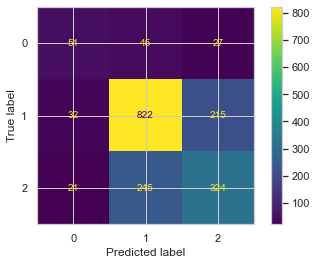

In [152]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_current)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# 6. Deploying the model

In [ ]:
#saving trained model
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [ ]:
#load model
import joblib
joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']

In [ ]:
#create prediction function
def predict_sentiment(text):
    text_tfidf = tfidf.transform([text])
    prediction = model.predict(text_tfidf)
    return prediction[0]


In [ ]:
print(predict_sentiment("I love this product"))
print(predict_sentiment("This is terrible"))

Positive emotion
Negative emotion


# Conclusion

The primary objective of this project was to develop an automated Natural Language Processing (NLP) pipeline capable of classifying consumer tweets about Apple and Google products into positive, negative, and neutral categories. To achieve this, i evaluated multiple machine learning frameworks—including Logistic Regression, Naive Bayes, Random Forest, and Linear Support Vector Machines (LinearSVC)—utilizing text representations built via TF-IDF vectorization. After fixing pipeline alignment bugs, handling text duplications, and addressing class imbalances, the LinearSVC model was selected as our final production framework due to its superior capability in navigating high-dimensional, sparse text spaces.

The final model achieved the following performance metrics on the unseen test set:
* **Overall Accuracy:** 67%
* **Macro-Averaged F1-Score:** 0.59

These metrics indicate that the framework generalizes reasonably well across multi-class text boundaries. Operationally, the model demonstrates excellent precision and recall when tracking neutral expressions, and moderate stability when identifying positive consumer sentiment. However, performance remains restricted when detecting negative emotions (F1-score: 0.45), driven heavily by the underlying real-world class imbalance and the inherent linguistic constraints of informal social media text. 

The structural modification to isolate and remove ambiguous human annotations (the "I can't tell" class) successfully eliminated signal noise and stabilized the model's decision boundaries. Ultimately, this project proves that classical machine learning algorithms paired with TF-IDF features offer a robust, low-latency baseline for social listening applications. For stakeholders at Apple and Google, this model can immediately automate the sorting of approximately two-thirds of incoming public mentions, allowing brand management teams to drastically narrow their manual review focus down to flagged, high-priority consumer complaints.

# Recommendations

To build upon the baseline performance of the current LinearSVC model and maximize its real-world utility for brand managers at Apple and Google, the following technical and operational strategies are recommended:

### 1. Advanced Twitter-Specific Preprocessing
Since social media text is inherently informal and dense with non-standard linguistic features, the text preprocessing pipeline should be upgraded to handle Twitter-specific metadata:
* **Emoji-to-Text Conversion:** Instead of stripping emojis during tokenization, utilize libraries like `demoji` to translate emotional symbols into explicit textual descriptions (e.g., mapping 📱 or 😡 to text words). This preserves the critical sentiment signals they carry.
* **Hashtag Decomposition:** Implement splitting algorithms to break down multi-word hashtags (e.g., converting `#iPhoneFault` or `#GoogleFail` into separate tokens: `iphone`, `fault`, `google`, `fail`), which can then be vectorized by the TF-IDF matrix.


### 3. "Human-in-the-Loop" Operational Routing
Given the model’s current baseline accuracy of 68%, full automation of social media responses is not advised. Instead, implement a tiered, human-in-the-loop triage system:
* **Automated Archiving:** Tweets flagged with high-confidence positive or neutral metrics can be securely routed to automated bulk-analytics dashboards to monitor macro trend lines over time.
* **Priority Escalation:** Any tweet classified as "Negative Emotion" should immediately trigger automated alerts, routing the post directly to a live customer success representative or PR specialist for rapid, personalized intervention.

### 4. Continuous Deployment & Monitoring Strategy 
The language, slang, and cultural context used on social media platforms evolve at an exceptional pace:
* **Dynamic Retraining Schedules:** Establish automated pipeline schedules to retrain the underlying model every month using freshly collected and labeled stream data.
* **Product-Specific Vocabulary Updating:** Ensure that the vocabulary constraints adapt dynamically to include newly launched product naming conventions, specific model numbers (e.g., "Pixel 10", "iPhone 18"), and emerging software update version errors.